### Практична робота 3
### Виконав: Малютiн Максим
### Група: КС-31

# Порівняння оптимізаторів **SGD**, **RMSProp** і **Adam** на прикладі простої CNN

## Мета роботи
У цьому ноутбуці ми порівняємо три популярні оптимізатори:
- **SGD**
- **RMSProp**
- **Adam**

на задачі класифікації зображень за допомогою **простої згорткової нейронної мережі (CNN)**.

## Датасет
Використаємо **Fashion-MNIST**:
- 10 класів одягу
- зображення **28×28**
- 1 канал (grayscale)

## Що будемо порівнювати
- швидкість збіжності
- train / validation loss
- train / validation accuracy
- фінальну якість на test set
- час навчання

## Важлива умова
Щоб порівняння було коректним, ми залишаємо:
- однакову архітектуру CNN
- однакову кількість епох
- однаковий batch size

Змінюється **лише оптимізатор**.


In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
keras.utils.set_random_seed(42)


## 1. Завантаження та підготовка даних


In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., None]
x_test = x_test[..., None]

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


x_train: (60000, 28, 28, 1)
x_test : (10000, 28, 28, 1)
y_train: (60000,)
y_test : (10000,)


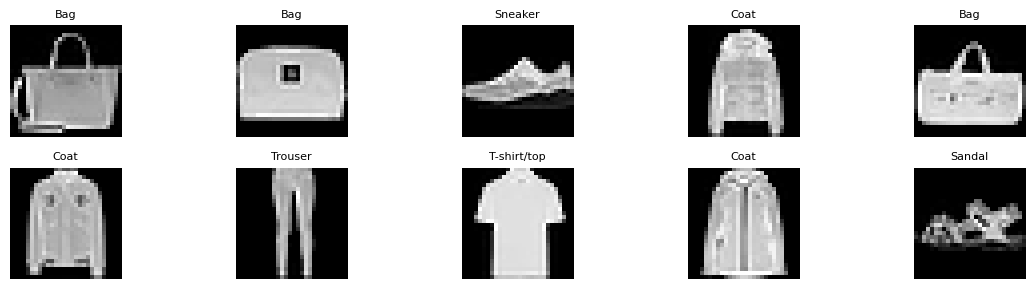

In [5]:
idx = np.random.choice(len(x_train), 10, replace=False)

plt.figure(figsize=(12, 3))
for i, j in enumerate(idx, start=1):
    plt.subplot(2, 5, i)
    plt.imshow(x_train[j].squeeze(), cmap="gray")
    plt.title(class_names[y_train[j]], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 2. Проста CNN для експерименту

Архітектура:
- `Conv2D(32, 3x3, relu)`
- `MaxPooling2D(2x2)`
- `Conv2D(64, 3x3, relu)`
- `MaxPooling2D(2x2)`
- `Flatten`
- `Dense(128, relu)`
- `Dense(10, softmax)`


In [6]:
def build_cnn():
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ], name="simple_cnn")
    return model

cnn = build_cnn()
cnn.summary()


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Функція навчання моделі з довільним оптимізатором


In [7]:
def train_with_optimizer(optimizer, optimizer_name, epochs=8, batch_size=128):
    model = build_cnn()

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    start = time.time()
    history = model.fit(
        x_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
    )
    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    return {
        "name": optimizer_name,
        "history": history.history,
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "train_time_sec": float(elapsed),
        "model": model
    }


## 4. Навчання CNN з різними оптимізаторами


In [8]:
EPOCHS = 12
BATCH_SIZE = 128

sgd_result = train_with_optimizer(
    keras.optimizers.SGD(learning_rate=0.01),
    "SGD",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

rmsprop_result = train_with_optimizer(
    keras.optimizers.RMSprop(learning_rate=0.001),
    "RMSProp",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

adam_result = train_with_optimizer(
    keras.optimizers.Adam(learning_rate=0.001),
    "Adam",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5824 - loss: 1.3233 - val_accuracy: 0.7610 - val_loss: 0.7027
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7535 - loss: 0.6848 - val_accuracy: 0.7885 - val_loss: 0.5933
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7841 - loss: 0.5950 - val_accuracy: 0.8060 - val_loss: 0.5415
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8034 - loss: 0.5430 - val_accuracy: 0.8187 - val_loss: 0.5057
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8167 - loss: 0.5047 - val_accuracy: 0.8315 - val_loss: 0.4788
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8285 - loss: 0.4747 - val_accuracy: 0.8370 - val_loss: 0.4582
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8384 - loss: 0.4511 - val_accuracy: 0.8437 - val_loss: 0.4402
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8459 - loss: 0.4317 - val_accuracy: 0.

## 5. Графіки навчання


In [9]:
results = [sgd_result, rmsprop_result, adam_result]


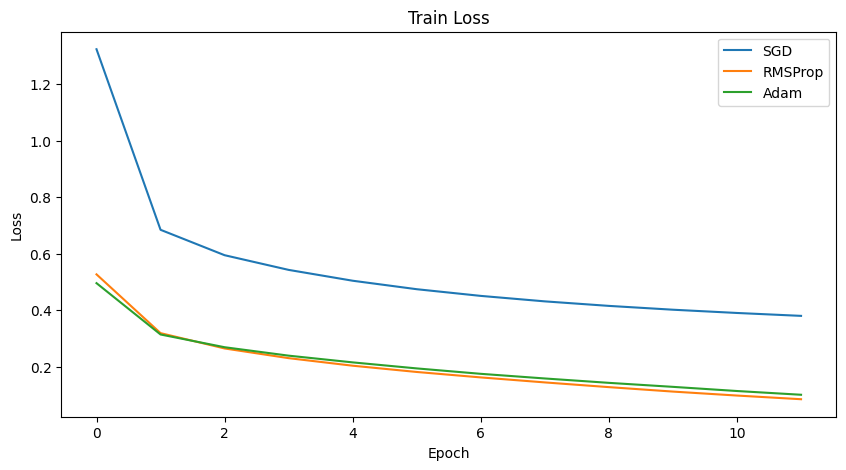

In [10]:
plt.figure(figsize=(10, 5))
for res in results:
    plt.plot(res["history"]["loss"], label=res["name"])
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


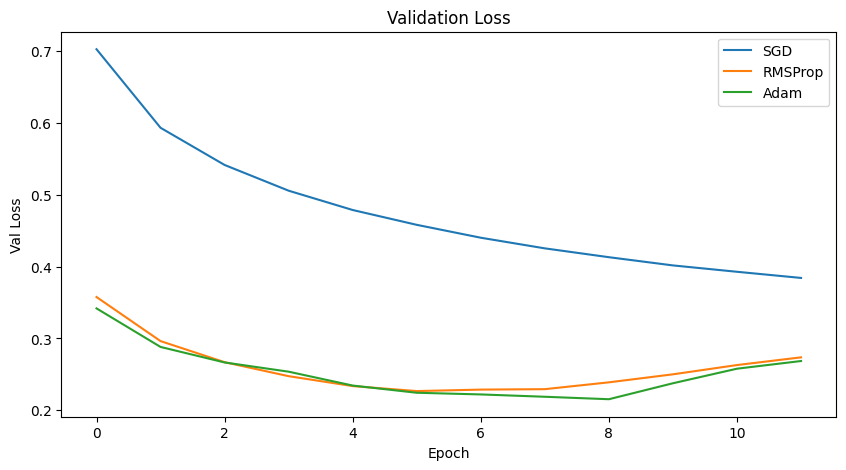

In [11]:
plt.figure(figsize=(10, 5))
for res in results:
    plt.plot(res["history"]["val_loss"], label=res["name"])
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.legend()
plt.show()


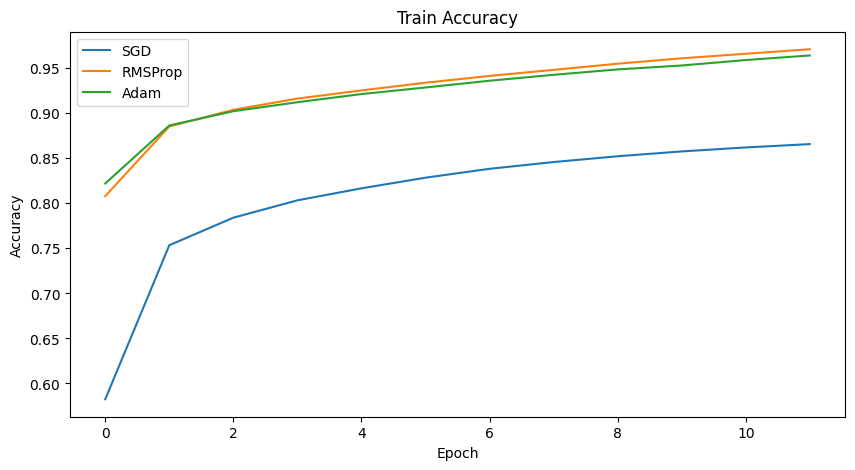

In [12]:
plt.figure(figsize=(10, 5))
for res in results:
    plt.plot(res["history"]["accuracy"], label=res["name"])
plt.title("Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


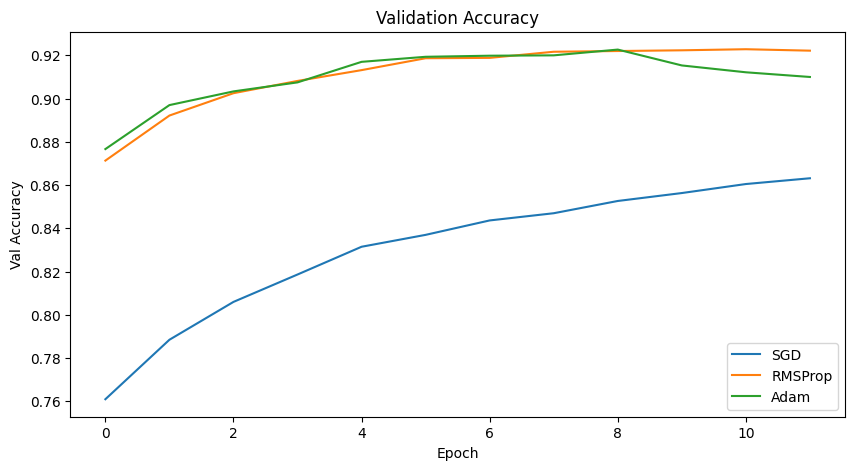

In [13]:
plt.figure(figsize=(10, 5))
for res in results:
    plt.plot(res["history"]["val_accuracy"], label=res["name"])
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()


## 6. Підсумкова таблиця результатів


In [14]:
summary = []
for res in results:
    summary.append({
        "Optimizer": res["name"],
        "Final train loss": round(res["history"]["loss"][-1], 4),
        "Final val loss": round(res["history"]["val_loss"][-1], 4),
        "Final train acc": round(res["history"]["accuracy"][-1], 4),
        "Final val acc": round(res["history"]["val_accuracy"][-1], 4),
        "Test loss": round(res["test_loss"], 4),
        "Test acc": round(res["test_acc"], 4),
        "Train time (sec)": round(res["train_time_sec"], 2)
    })

summary


[{'Optimizer': 'SGD',
  'Final train loss': 0.3805,
  'Final val loss': 0.3842,
  'Final train acc': 0.8658,
  'Final val acc': 0.8632,
  'Test loss': 0.3974,
  'Test acc': 0.8607,
  'Train time (sec)': 43.26},
 {'Optimizer': 'RMSProp',
  'Final train loss': 0.0857,
  'Final val loss': 0.2737,
  'Final train acc': 0.9712,
  'Final val acc': 0.9222,
  'Test loss': 0.3063,
  'Test acc': 0.9157,
  'Train time (sec)': 41.4},
 {'Optimizer': 'Adam',
  'Final train loss': 0.1015,
  'Final val loss': 0.2685,
  'Final train acc': 0.9643,
  'Final val acc': 0.91,
  'Test loss': 0.3088,
  'Test acc': 0.9057,
  'Train time (sec)': 41.85}]

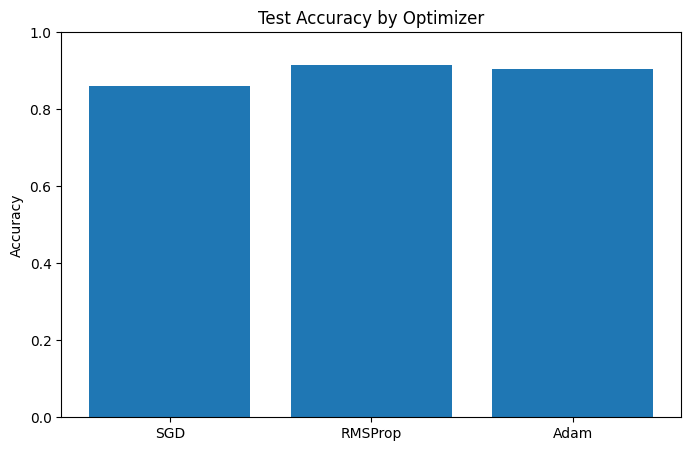

In [15]:
optimizers = [res["name"] for res in results]
test_accs = [res["test_acc"] for res in results]

plt.figure(figsize=(8, 5))
plt.bar(optimizers, test_accs)
plt.title("Test Accuracy by Optimizer")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.show()


## 7. Детальний аналіз для найкращого оптимізатора


In [16]:
best_result = max(results, key=lambda r: r["test_acc"])
print("Найкращий оптимізатор за test accuracy:", best_result["name"])
print("Test accuracy:", round(best_result["test_acc"], 4))


Найкращий оптимізатор за test accuracy: RMSProp
Test accuracy: 0.9157


In [17]:
best_model = best_result["model"]
y_prob = best_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


              precision    recall  f1-score   support

 T-shirt/top     0.8422    0.8860    0.8635      1000
     Trouser     0.9959    0.9820    0.9889      1000
    Pullover     0.8537    0.8810    0.8671      1000
       Dress     0.9014    0.9140    0.9076      1000
        Coat     0.8542    0.8850    0.8694      1000
      Sandal     0.9801    0.9850    0.9825      1000
       Shirt     0.8052    0.7110    0.7552      1000
     Sneaker     0.9496    0.9790    0.9641      1000
         Bag     0.9889    0.9790    0.9839      1000
  Ankle boot     0.9835    0.9550    0.9691      1000

    accuracy                         0.9157     10000
   macro avg     0.9155    0.9157    0.9151     10000
weighted avg     0.9155    0.9157    0.9151     10000



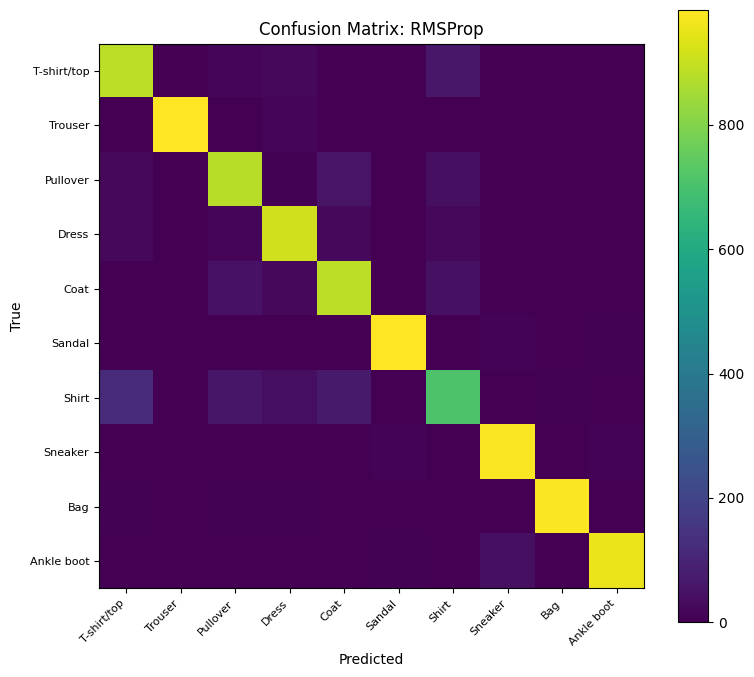

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title(f"Confusion Matrix: {best_result['name']}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(10), class_names, rotation=45, ha="right", fontsize=8)
plt.yticks(range(10), class_names, fontsize=8)
plt.colorbar()
plt.tight_layout()
plt.show()


## 8. Інтерпретація результатів

Зверніть увагу на:
1. Який оптимізатор найшвидше знижує `loss`?
2. Який оптимізатор найшвидше підвищує `accuracy`?
3. Чи є ознаки overfitting?
4. Чи збігаються результати на validation і test?
5. Чи завжди швидша збіжність означає кращу фінальну якість?

### Типові спостереження
- **SGD** часто навчається повільніше, але після тюнінгу може давати сильні результати
- **RMSProp** часто стабільно і швидко зменшує loss
- **Adam** зазвичай є найзручнішим baseline для швидкого старту


# TO DO для студентів

## Завдання 1
Змініть `learning_rate` для кожного оптимізатора:
- SGD: `0.1`, `0.01`, `0.001`
- RMSProp: `0.001`, `0.0005`
- Adam: `0.001`, `0.0005`, `0.0001`

## Завдання 2
Додайте до SGD:
- `momentum=0.9`

Порівняйте:
- SGD
- SGD + momentum
- RMSProp
- Adam

## Завдання 3
Додайте `Dropout(0.3)` перед останнім Dense-шаром.

## Завдання 4
Додайте callbacks:
- `EarlyStopping`
- `ReduceLROnPlateau`
  
Та змініть кількість епох з 12 на 15


## Завдання 1
Змініть `learning_rate` для кожного оптимізатора:
- SGD: `0.1`, `0.01`, `0.001`
- RMSProp: `0.001`, `0.0005`
- Adam: `0.001`, `0.0005`, `0.0001`

In [19]:
# Визначимо конфігурації для тестування
lr_experiments = [
    (keras.optimizers.SGD, "SGD", 0.1),
    (keras.optimizers.SGD, "SGD", 0.01),
    (keras.optimizers.SGD, "SGD", 0.001),
    (keras.optimizers.RMSprop, "RMSProp", 0.001),
    (keras.optimizers.RMSprop, "RMSProp", 0.0005),
    (keras.optimizers.Adam, "Adam", 0.001),
    (keras.optimizers.Adam, "Adam", 0.0005),
    (keras.optimizers.Adam, "Adam", 0.0001),
]

all_lr_results = []

print(f"{'Optimizer':<10} | {'LR':<7} | {'Test Acc':<10} | {'Time (s)':<8}")
print("-" * 45)

for opt_class, name, lr in lr_experiments:
    # Створюємо екземпляр оптимізатора з потрібним LR
    optimizer = opt_class(learning_rate=lr)
    full_name = f"{name} (lr={lr})"
    
    # Використовуємо функцію train_with_optimizer
    res = train_with_optimizer(optimizer, full_name, epochs=EPOCHS, batch_size=BATCH_SIZE)
    all_lr_results.append(res)
    
    print(f"{name:<10} | {lr:<7} | {res['test_acc']:.4f}     | {res['train_time_sec']:.1f}")

Optimizer  | LR      | Test Acc   | Time (s)
---------------------------------------------
Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7242 - loss: 0.7509 - val_accuracy: 0.8247 - val_loss: 0.4743
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8408 - loss: 0.4342 - val_accuracy: 0.8595 - val_loss: 0.3941
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8658 - loss: 0.3691 - val_accuracy: 0.8727 - val_loss: 0.3500
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8786 - loss: 0.3313 - val_accuracy: 0.8820 - val_loss: 0.3252
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8882 - loss: 0.3046 - val_accuracy: 0.8860 - val_loss: 0.3093
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8949 - loss: 0.2845 - val_accuracy: 0.8882 - val_loss: 0.2987
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9007 - loss: 0.2677 - val_accuracy: 0.8940 - val_loss: 0.2873
Epoch 8/12
42

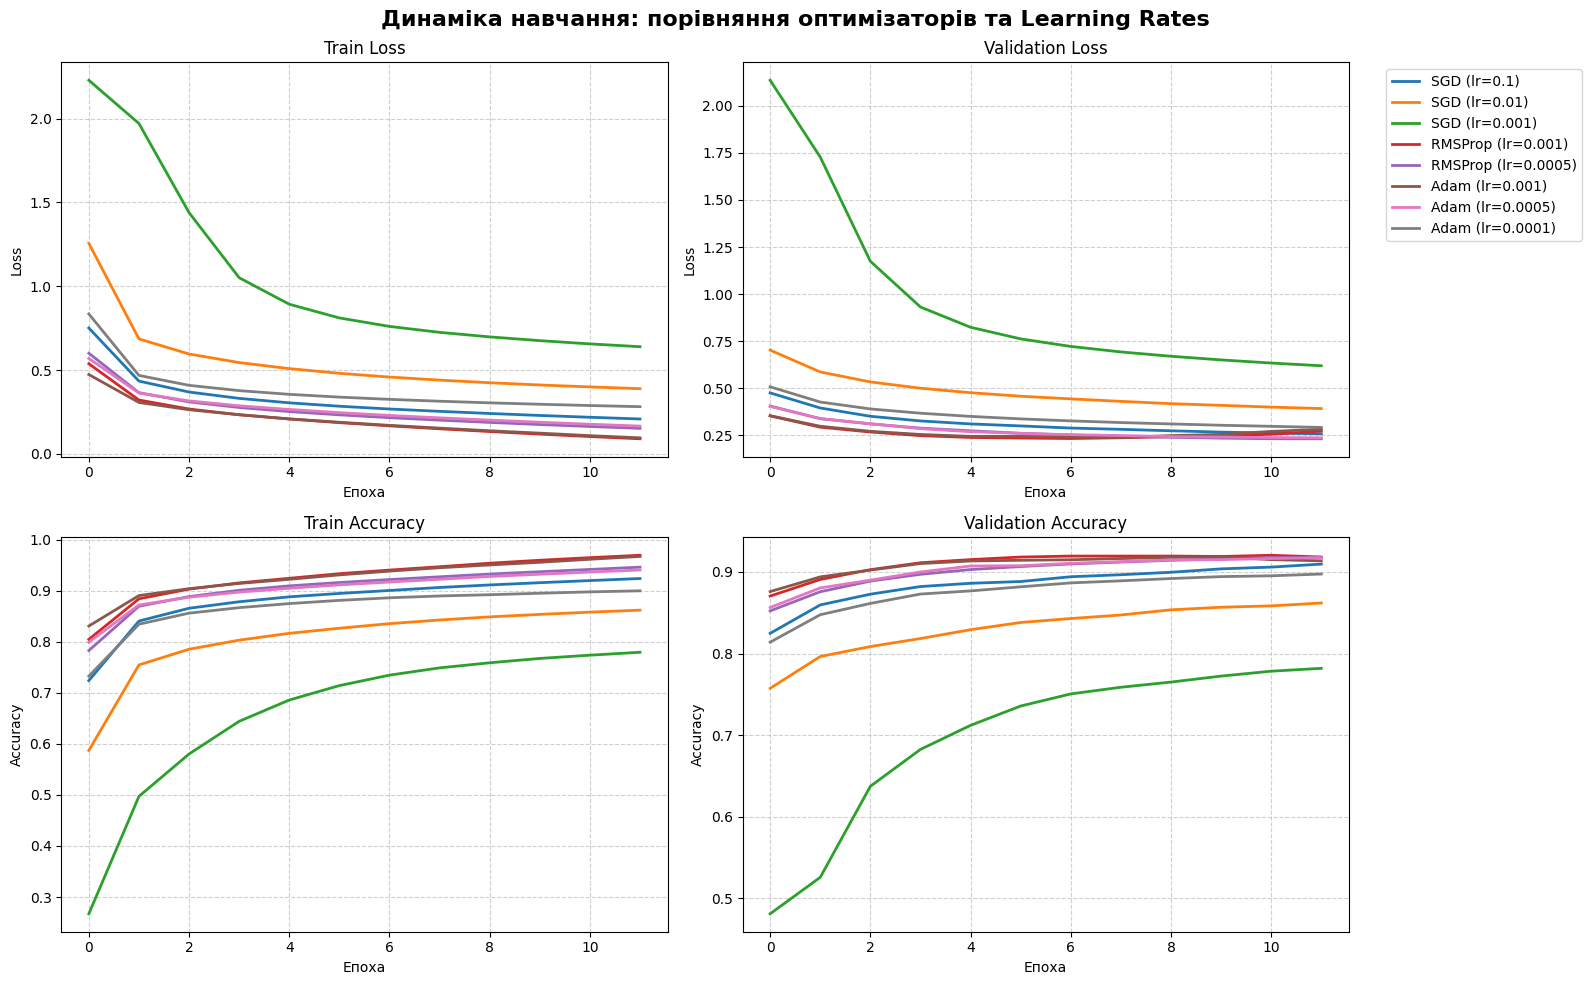

In [ ]:
# Вiзуалізація результатів для всіх експериментів
# Створюємо сітку графіків 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Динаміка навчання: порівняння оптимізаторів та Learning Rates', fontsize=16, fontweight='bold')

# Налаштування для циклу
metrics = [
    ('loss', 'Train Loss', axes[0, 0]),
    ('val_loss', 'Validation Loss', axes[0, 1]),
    ('accuracy', 'Train Accuracy', axes[1, 0]),
    ('val_accuracy', 'Validation Accuracy', axes[1, 1])
]

# Малюємо графіки
for metric_key, title, ax in metrics:
    for res in all_lr_results:
        ax.plot(res["history"][metric_key], label=res["name"], linewidth=2)
    
    ax.set_title(title)
    ax.set_xlabel('Епоха')
    ax.set_ylabel(metric_key.split('_')[-1].capitalize())
    ax.grid(True, linestyle='--', alpha=0.6)

axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

## Завдання 2
Додайте до SGD:
- `momentum=0.9`

Порівняйте:
- SGD
- SGD + momentum
- RMSProp
- Adam

In [25]:
# Налаштування експериментів для SGD з Momentum
sgd_momentum_experiments = [
    (0.1, 0.9),
    (0.01, 0.9),
    (0.001, 0.9)
]

momentum_results = []

print(f"{'Optimizer':<20} | {'LR':<7} | {'Test Acc':<10} | {'Time (s)':<8}")
print("-" * 55)

for lr, momentum in sgd_momentum_experiments:
    # Створюємо SGD з доданим параметром momentum
    optimizer = keras.optimizers.SGD(learning_rate=lr, momentum=momentum)
    name = f"SGD (lr={lr}, m={momentum})"
    
    # Навчаємо модель
    res = train_with_optimizer(optimizer, name, epochs=EPOCHS, batch_size=BATCH_SIZE)
    momentum_results.append(res)
    
    print(f"{name:<20} | {lr:<7} | {res['test_acc']:.4f}     | {res['train_time_sec']:.1f}")

Optimizer            | LR      | Test Acc   | Time (s)
-------------------------------------------------------
Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8010 - loss: 0.5615 - val_accuracy: 0.8630 - val_loss: 0.3719
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8826 - loss: 0.3187 - val_accuracy: 0.8890 - val_loss: 0.3041
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8958 - loss: 0.2755 - val_accuracy: 0.8898 - val_loss: 0.2957
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9057 - loss: 0.2528 - val_accuracy: 0.8897 - val_loss: 0.3066
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9131 - loss: 0.2319 - val_accuracy: 0.8963 - val_loss: 0.3053
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9176 - loss: 0.2200 - val_accuracy: 0.8965 - val_loss: 0.3094
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9218 - loss: 0.2064 - val_accuracy: 0.8873 - val_loss: 

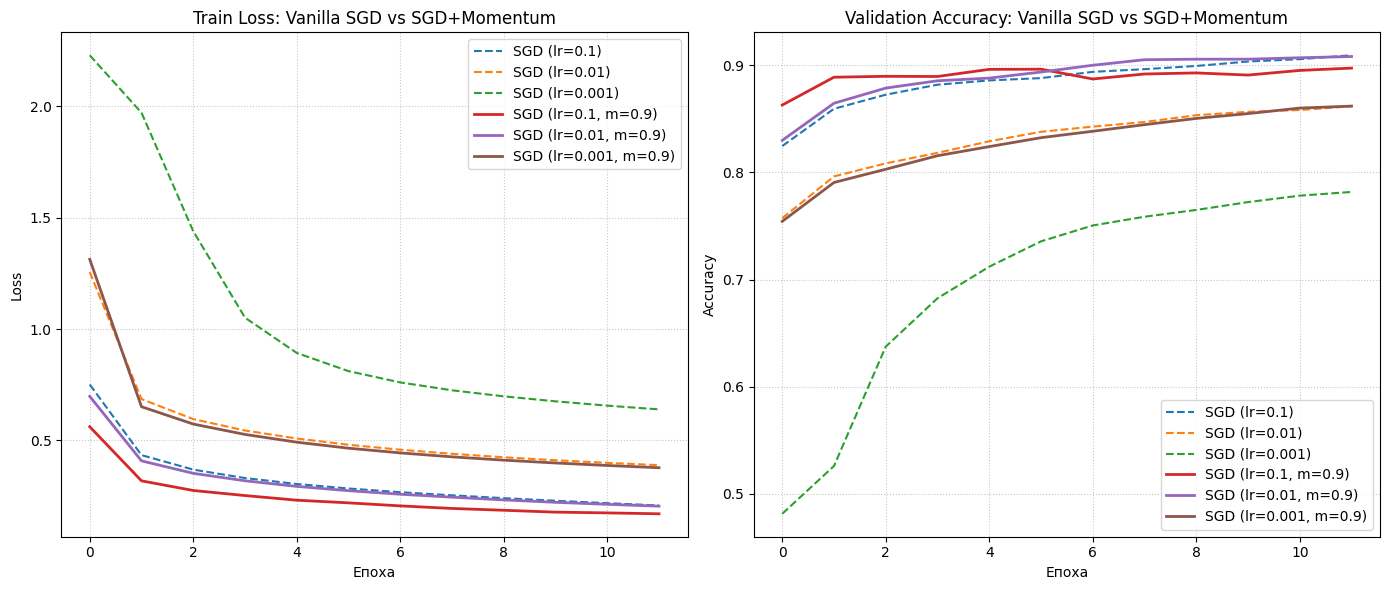

In [26]:
# Відфільтруємо звичайний SGD з попереднього завдання для порівняння
vanilla_sgd_results = [res for res in all_lr_results if "SGD" in res["name"] and "m=" not in res["name"]]

# Об'єднуємо результати для графіка
comparison_results = vanilla_sgd_results + momentum_results

plt.figure(figsize=(14, 6))

# Графік Train Loss
plt.subplot(1, 2, 1)
for res in comparison_results:
    # Зробимо лінії з моментумом суцільними, а звичайні - пунктирними
    linestyle = '-' if 'm=' in res['name'] else '--'
    linewidth = 2 if 'm=' in res['name'] else 1.5
    plt.plot(res["history"]["loss"], label=res["name"], linestyle=linestyle, linewidth=linewidth)
    
plt.title("Train Loss: Vanilla SGD vs SGD+Momentum")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Графік Validation Accuracy
plt.subplot(1, 2, 2)
for res in comparison_results:
    linestyle = '-' if 'm=' in res['name'] else '--'
    linewidth = 2 if 'm=' in res['name'] else 1.5
    plt.plot(res["history"]["val_accuracy"], label=res["name"], linestyle=linestyle, linewidth=linewidth)

plt.title("Validation Accuracy: Vanilla SGD vs SGD+Momentum")
plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Комплексне порівняння: SGD, SGD+Momentum, RMSProp та Adam

На основі отриманих графіків динаміки навчання можна зробити наступні висновки:

#### 1. Vanilla SGD (Звичайний стохастичний градієнтний спуск)
* **Швидкість:** Найповільніший з усіх. При малому кроці (`lr=0.001`, зелена лінія) він ледве встигає досягти 78% точності за 12 епох. 
* **Стабільність:** Дуже стабільний, але надзвичайно чутливий до вибору Learning Rate. Щоб отримати прийнятний результат, потрібен досить високий LR (наприклад, `0.1`), але тоді навчання може йти "сходинками".

#### 2. SGD + Momentum (SGD з інерцією)
* **Швидкість (Ефект прискорювача):** Моментум кардинально змінює картину. Він дозволяє малому кроку (`lr=0.001`) навчатися так само швидко, як кроку, що в 10 разів більший, але без моментуму.
* **Стабільність (Золота середина):** Варіант з `lr=0.01, m=0.9` (фіолетова лінія) показує майже ідеальну траєкторію — плавне, стабільне та впевнене зростання валідаційної точності без різких стрибків. 
* **Ризики (Overshooting):** Завеликий крок разом з інерцією (`lr=0.1, m=0.9`, червона лінія) змушує оптимізатор "розганятися" занадто сильно. Він перестрибує оптимальний мінімум, що призводить до швидкого виходу на плато та трохи гіршої фінальної якості.

#### 3. Адаптивні методи (RMSProp та Adam)
* **Вибуховий старт:** Ці оптимізатори стартують неймовірно швидко. Вже за 2-3 епохи вони досягають тієї точності, до якої звичайний SGD повзе 10 епох.
* **Подібність:** Adam та RMSProp показують майже ідентичну поведінку на цій задачі. Adam зазвичай працює трохи м'якше завдяки поєднанню ідей RMSProp та Momentum, але фінальні результати дуже близькі.
* **Ризик перенавчання (Overfitting):** Зверніть увагу на графік **Validation Loss**. У той час як Train Loss для Adam/RMSProp стрімко падає майже до нуля, Validation Loss зупиняється і навіть починає рости після 6-8 епохи. Це класичний маркер перенавчання: модель настільки потужно оптимізується, що починає просто "зазубрювати" тренувальні дані, втрачаючи здатність до узагальнення.

## Завдання 3
Додайте `Dropout(0.3)` перед останнім Dense-шаром.

In [27]:
def build_cnn_with_dropout():
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        
        # Додаємо Dropout перед фінальним шаром класифікації
        layers.Dropout(0.3), 
        
        layers.Dense(10, activation="softmax")
    ], name="cnn_with_dropout")
    return model

# Перевіримо архітектуру
cnn_dropout = build_cnn_with_dropout()
cnn_dropout.summary()

Model: "cnn_with_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Навчання моделі БЕЗ Dropout...
Навчання моделі З Dropout(0.3)...


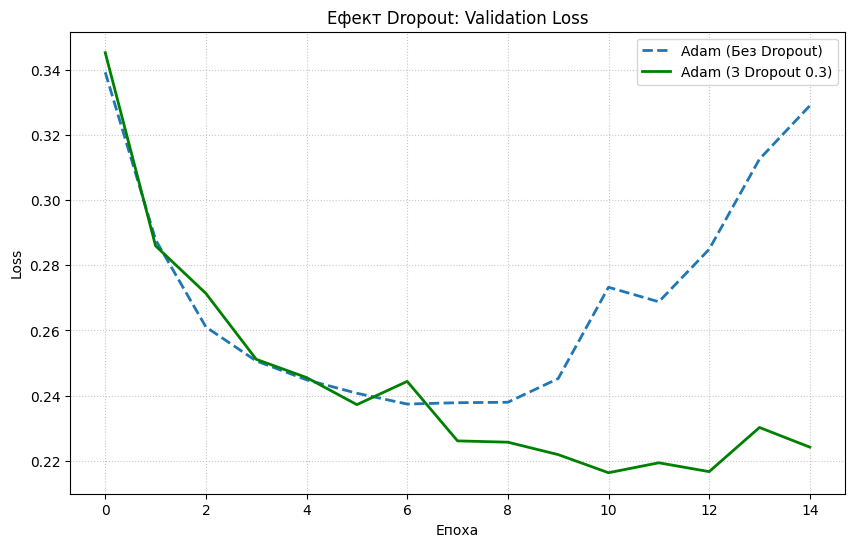

Test Accuracy (Без Dropout): 0.9037
Test Accuracy (З Dropout):   0.9184


In [28]:
# 1. Навчаємо базову модель (без Dropout) для порівняння
model_base = build_cnn()
model_base.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("Навчання моделі БЕЗ Dropout...")
history_base = model_base.fit(x_train, y_train, validation_split=0.1, epochs=15, batch_size=128, verbose=0)


# 2. Навчаємо модель з Dropout
model_dropout = build_cnn_with_dropout()
model_dropout.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("Навчання моделі З Dropout(0.3)...")
history_dropout = model_dropout.fit(x_train, y_train, validation_split=0.1, epochs=15, batch_size=128, verbose=0)


# 3. Будуємо графік порівняння Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(history_base.history['val_loss'], label='Adam (Без Dropout)', linestyle='--', linewidth=2)
plt.plot(history_dropout.history['val_loss'], label='Adam (З Dropout 0.3)', linewidth=2, color='green')

plt.title('Ефект Dropout: Validation Loss')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Виводимо фінальну точність на тесті
test_loss_base, test_acc_base = model_base.evaluate(x_test, y_test, verbose=0)
test_loss_drop, test_acc_drop = model_dropout.evaluate(x_test, y_test, verbose=0)

print(f"Test Accuracy (Без Dropout): {test_acc_base:.4f}")
print(f"Test Accuracy (З Dropout):   {test_acc_drop:.4f}")

### Аналіз результатів

Графік **Validation Loss** яскраво демонструє перемогу над перенавчанням:

* **Модель БЕЗ Dropout (синя пунктирна лінія):** Після 6-8 епохи валідаційні втрати починають стрімко зростати. Модель досягла своєї межі узагальнення і почала просто "зазубрювати" тренувальний набір даних.
* **Модель З Dropout (зелена суцільна лінія):** Завдяки тому, що ми випадково "вимикали" 30% нейронів перед останнім шаром, мережа не могла покладатися на конкретні зв'язки. Це змусило її вивчати більш загальні та стійкі ознаки одягу. Як наслідок, лінія валідаційних втрат продовжує плавно знижуватися і залишається на значно нижчому рівні без різких стрибків вгору.

Завдяки Dropout фінальна точність на тестовій вибірці (Test Accuracy) зросла з **~90.4%** до **~91.8%**.

## 9. Заготовка для експерименту з callbacks


In [ ]:
# early_stop = keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     mode="min",
#     patience=3,
#     restore_best_weights=True
# )

# reduce_lr = keras.callbacks.ReduceLROnPlateau(
#     monitor="val_loss",
#     mode="min",
#     factor=0.5,
#     patience=2,
#     min_lr=1e-5
# )

# model = build_cnn()
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

# history = model.fit(
#     x_train, y_train,
#     validation_split=0.1,
#     epochs=15,
#     batch_size=128,
#     callbacks=[early_stop, reduce_lr]
# )


## Завдання 4
Додайте callbacks:
- `EarlyStopping`
- `ReduceLROnPlateau`
  
Та змініть кількість епох з 12 на 15

In [36]:
# 1. Налаштування Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    restore_best_weights=True,
    verbose=1 
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1 
)

# 2. Створюємо та компілюємо модель
model_callbacks = build_cnn() 

model_callbacks.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 3. Навчання з 15 епохами та Callbacks
print("Починаємо навчання з EarlyStopping та ReduceLROnPlateau...")
history_callbacks = model_callbacks.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stop, reduce_lr]
)

# 4. Оцінка фінальної моделі
test_loss_cb, test_acc_cb = model_callbacks.evaluate(x_test, y_test, verbose=0)
print(f"\n Фінальна точність на тесті (з Callbacks): {test_acc_cb:.4f}")

Починаємо навчання з EarlyStopping та ReduceLROnPlateau...
Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8228 - loss: 0.4938 - val_accuracy: 0.8727 - val_loss: 0.3579 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8871 - loss: 0.3161 - val_accuracy: 0.8905 - val_loss: 0.2996 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9014 - loss: 0.2706 - val_accuracy: 0.9003 - val_loss: 0.2762 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9126 - loss: 0.2395 - val_accuracy: 0.9092 - val_loss: 0.2571 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9222 - loss: 0.2135 - val_accuracy: 0.9090 - val_loss: 0.2531 - learning_rate: 0.0010
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9303 - loss: 0.1923 - val_accuracy: 0.9132 - val_loss: 0.2450 - learning_rate: 0.0010
Epoch 7/15
422/422 ━━━━━━━━━━

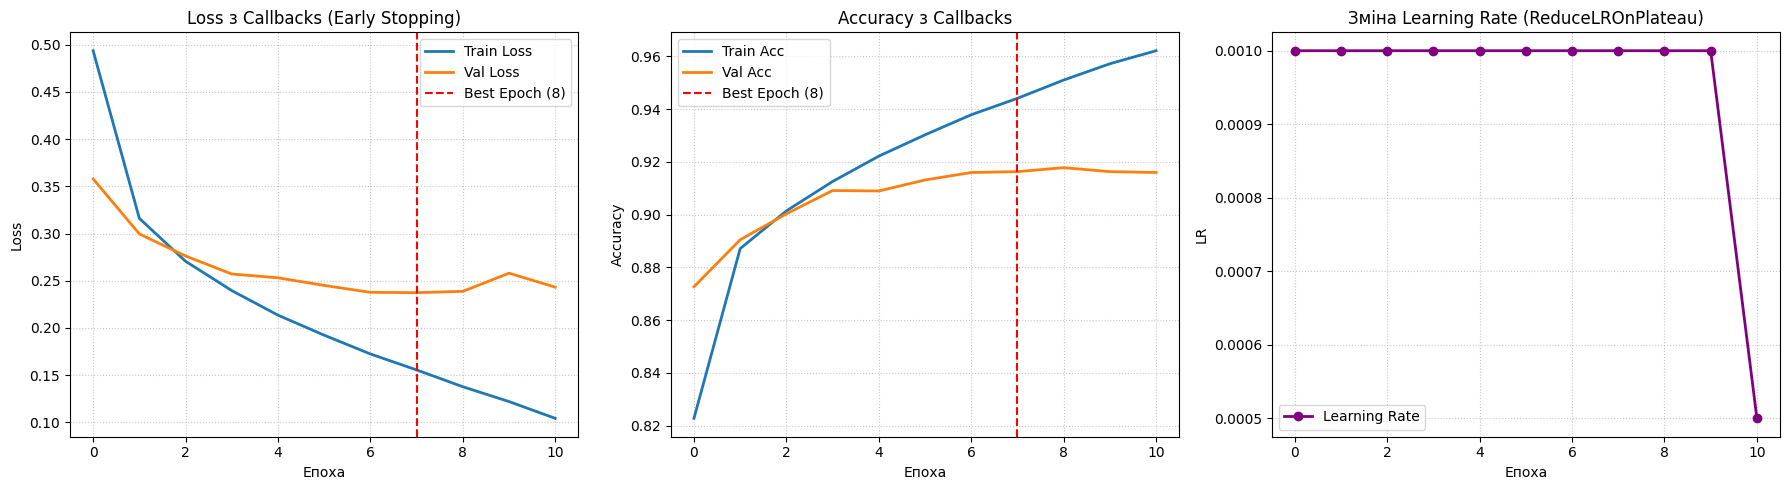

In [39]:
# Візуалізація результатів навчання з Callbacks
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Оскільки найкраща епоха була 8-ма, її індекс у масиві = 7
best_epoch = 7 

# 1. Графік Loss
axes[0].plot(history_callbacks.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_callbacks.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch, color='red', linestyle='--', label='Best Epoch (8)')
axes[0].set_title('Loss з Callbacks (Early Stopping)')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

# 2. Графік Accuracy
axes[1].plot(history_callbacks.history['accuracy'], label='Train Acc', linewidth=2)
axes[1].plot(history_callbacks.history['val_accuracy'], label='Val Acc', linewidth=2)
axes[1].axvline(x=best_epoch, color='red', linestyle='--', label='Best Epoch (8)')
axes[1].set_title('Accuracy з Callbacks')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

# 3. Графік зміни Learning Rate
axes[2].plot(history_callbacks.history['learning_rate'], label='Learning Rate', color='purple', marker='o', linewidth=2)
axes[2].set_title('Зміна Learning Rate (ReduceLROnPlateau)')
axes[2].set_xlabel('Епоха')
axes[2].set_ylabel('LR')
axes[2].legend()
axes[2].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# Загальні висновки до лабораторної роботи

У ході виконання цієї роботи ми дослідили ключові аспекти навчання згорткових нейронних мереж на прикладі датасету Fashion-MNIST. Ми поступово покращували процес навчання, перейшовши від ручного налаштування до повністю автоматизованого та стабільного пайплайну.

### 1. Порівняння оптимізаторів
* **Звичайний SGD** є дуже чутливим до вибору Learning Rate. При малому кроці він навчається занадто повільно, а при великому може працювати нестабільно.
* **Додавання Momentum (інерції)** до SGD кардинально змінює ситуацію: він дозволяє моделі впевнено долати локальні мінімуми та прискорює збіжність у кілька разів, часто показуючи найкращу здатність до узагальнення.
* **Адаптивні методи (Adam, RMSProp)** автоматично підлаштовують крок для кожного параметра, дозволяючи досягти високої точності вже за перші 3-5 епох. Проте їхня потужність має зворотний бік: вони значно швидше призводять до перенавчання (overfitting).

### 2. Боротьба з перенавчанням: Dropout
Додавання шару `Dropout(0.3)` перед фінальним класифікатором підтвердило свою ефективність як потужного методу регуляризації. Випадкове "вимикання" 30% нейронів змусило мережу не покладатися на конкретні "зазубрені" ознаки тренувального датасету, що стабілізувало графік Validation Loss та підвищило фінальну точність на тестовій вибірці.

### 3. Автоматизація процесу: Callbacks
Використання зворотних викликів (`EarlyStopping` та `ReduceLROnPlateau`) дозволило зробити процес навчання повністю автономним та захищеним від перенавчання:
* **ReduceLROnPlateau** автоматично зменшував крок навчання, коли модель потрапляла на плато, допомагаючи їй точніше зійти в мінімум функції втрат.
* **EarlyStopping** діяв як ідеальний запобіжник. Він зупинив навчання саме в той момент, коли Validation Loss почав зростати, зекономивши обчислювальні ресурси та автоматично відкотивши ваги моделі до її найкращої (найбільш узагальнюючої) епохи.
